In [ ]:
!pip install lightgbm xgboost catboost --quiet

In [ ]:
# import library

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, VotingClassifier
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
print("✅ Libraries loaded successfully")


✅ Libraries loaded successfully


In [ ]:
# Load Data
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print(f"Train shape : {train.shape}")
print(f"Test shape : {test.shape}")
print("\nTrain sample:")
train.head()

Train shape : (594194, 21)
Test shape : (254655, 20)

Train sample:


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


#EDA

In [ ]:
print("=== DATA TYPES & NULL VALUES ===")
info = pd.DataFrame({
    'dtype' : train.dtypes,
    'nulls' : train.isnull().sum(),
    'null_%': (train.isnull().sum() / len(train) * 100).round(2),
    'unique': train.nunique()
})
print(info)

=== DATA TYPES & NULL VALUES ===
                    dtype  nulls  null_%  unique
id                  int64      0     0.0  594194
gender             object      0     0.0       2
SeniorCitizen       int64      0     0.0       2
Partner            object      0     0.0       2
Dependents         object      0     0.0       2
tenure              int64      0     0.0      72
PhoneService       object      0     0.0       2
MultipleLines      object      0     0.0       3
InternetService    object      0     0.0       3
OnlineSecurity     object      0     0.0       3
OnlineBackup       object      0     0.0       3
DeviceProtection   object      0     0.0       3
TechSupport        object      0     0.0       3
StreamingTV        object      0     0.0       3
StreamingMovies    object      0     0.0       3
Contract           object      0     0.0       3
PaperlessBilling   object      0     0.0       2
PaymentMethod      object      0     0.0       4
MonthlyCharges    float64      0    

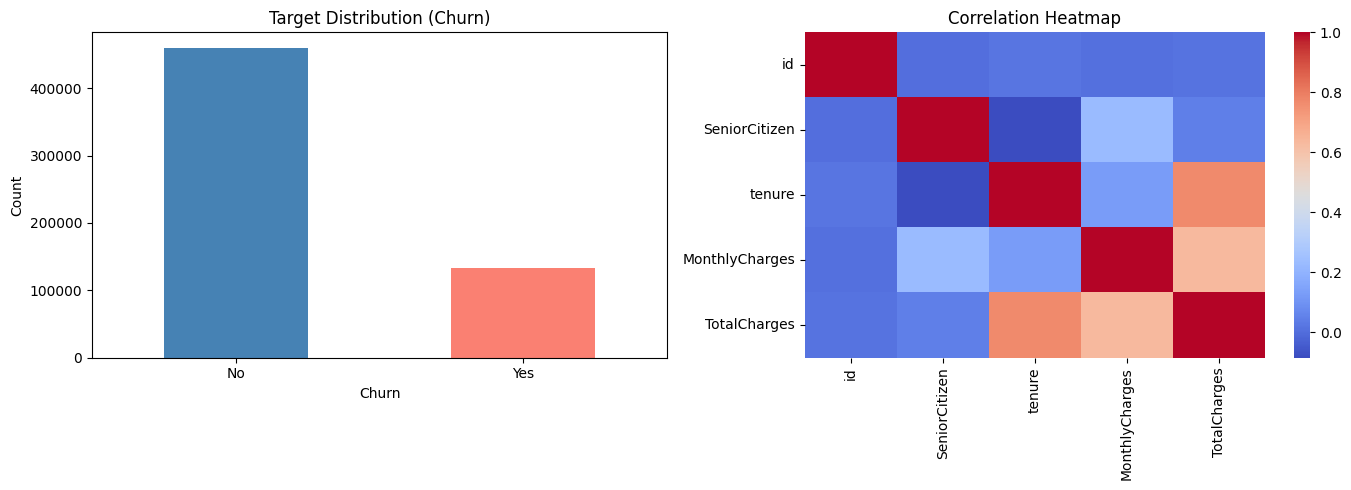

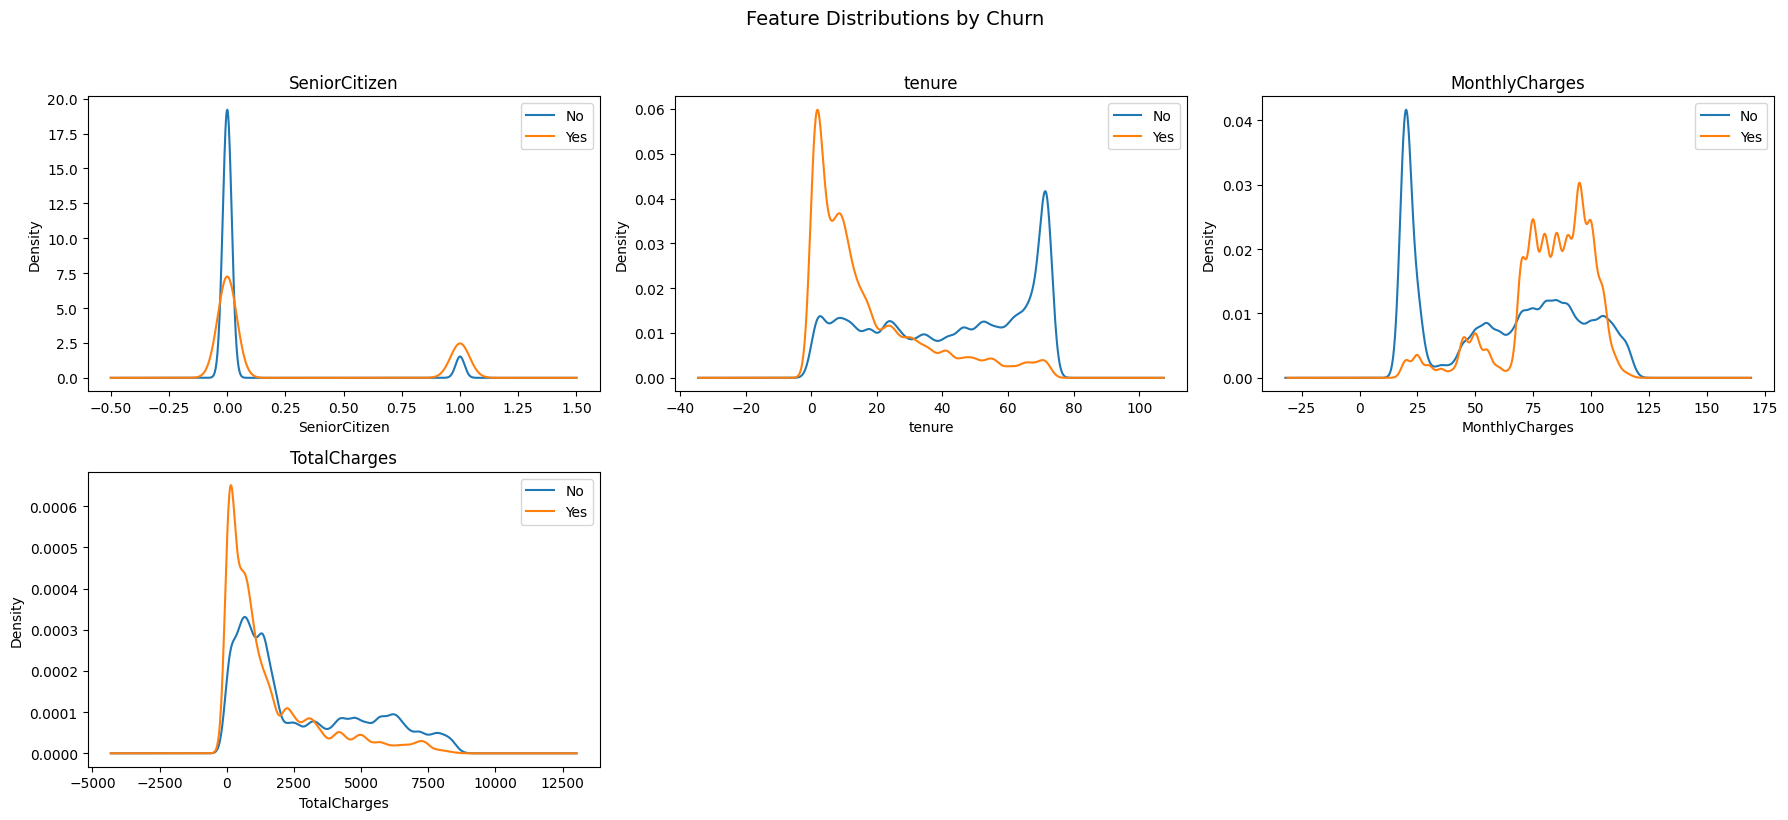

In [ ]:
# Cell 4: EDA - Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Target distribution
train['Churn'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'])
axes[0].set_title('Target Distribution (Churn)')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)

# Correlation heatmap (numeric only)
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
corr = train[numeric_cols].corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', ax=axes[1], fmt='.1f')
axes[1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

# Distribution of numeric features by Churn
numeric_features = [c for c in numeric_cols if c not in ['id', 'Churn']]
n = len(numeric_features)
if n > 0:
    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))
    axes = axes.flatten()
    for i, col in enumerate(numeric_features):
        train.groupby('Churn')[col].plot(kind='kde', ax=axes[i], legend=True, title=col)
        axes[i].set_xlabel(col)
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Feature Distributions by Churn', y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

grafik distribusi tersebut menunjukkan bahwa jumlah pelanggan dengan status "No Churn" jauh lebih banyak dibandingkan "Yes Churn" Hal ini menandakan dataset memiliki ketidakseimbangan kelas (imbalanced dataset), sehingga perlu diperhatikan saat proses pelatihan model machine learning agar model tidak bias terhadap kelas mayoritas.

Correlation Heatmap
Heatmap menunjukkan hubungan antar fitur numerik pada dataset.

*  tenure memiliki korelasi positif yang cukup kuat dengan TotalCharges, yang berarti semakin lama pelanggan berlangganan, semakin besar total biaya yang dibayarkan.
*  MonthlyCharges juga berkorelasi positif dengan TotalCharges, karena biaya bulanan yang lebih tinggi akan meningkatkan total pembayaran pelanggan.
*  Fitur SeniorCitizen memiliki korelasi yang relatif lemah terhadap fitur lainnya.
*  Kolom id tidak memiliki hubungan berarti dengan fitur lain sehingga kemungkinan tidak memberikan kontribusi penting dalam proses prediksi.





Churn Rate: 22.52%


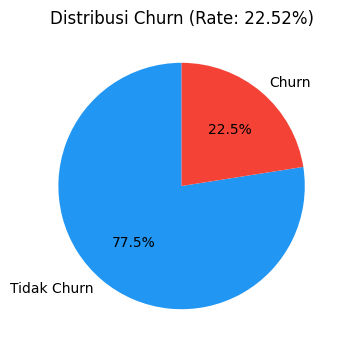

In [ ]:
# Konversi Churn ke numerik dulu
train['Churn'] = train['Churn'].map({'Yes': 1, 'No': 0})

# Sekarang baru hitung
churn_rate = train['Churn'].mean()
print(f"Churn Rate: {churn_rate:.2%}")

fig, ax = plt.subplots(figsize=(6, 4))
colors = ['#2196F3', '#F44336']
wedges, texts, autotexts = ax.pie(
    train['Churn'].value_counts(),
    labels=['Tidak Churn', 'Churn'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90
)
ax.set_title(f'Distribusi Churn (Rate: {churn_rate:.2%})')
plt.show()

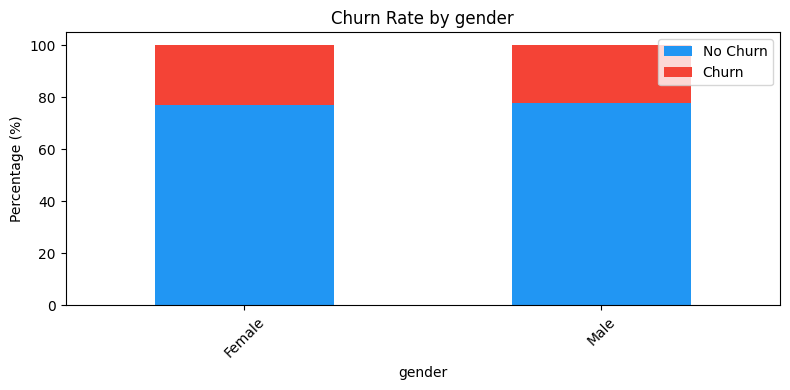

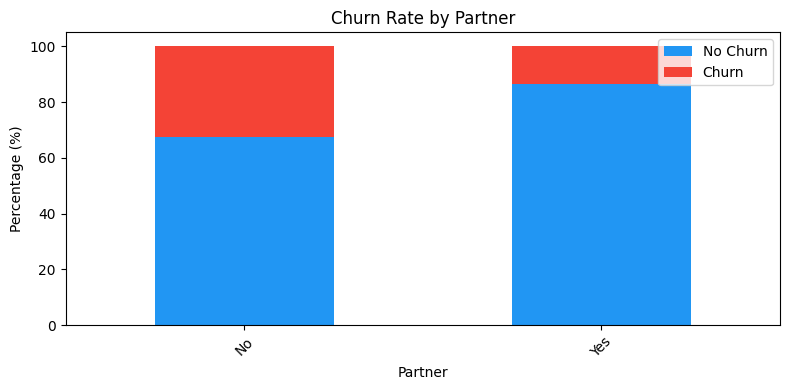

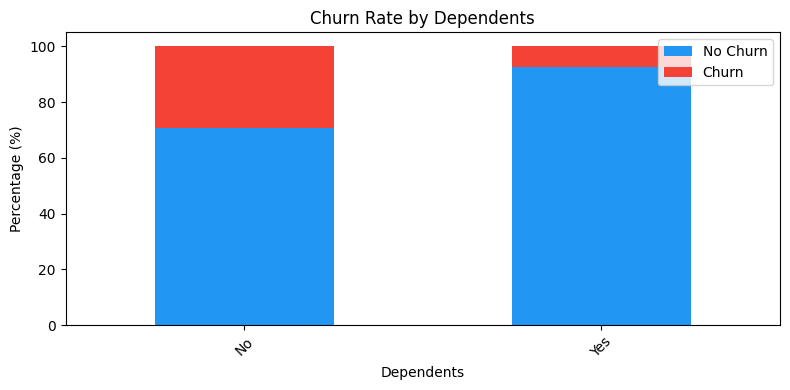

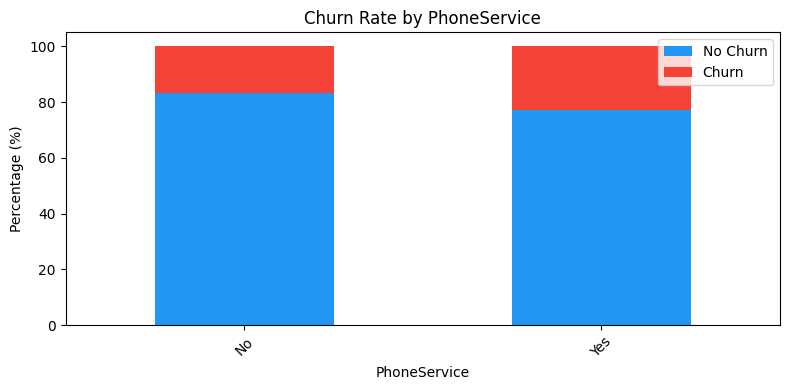

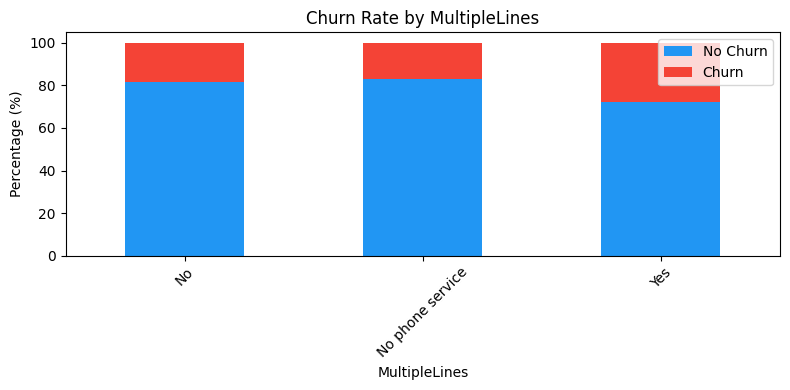

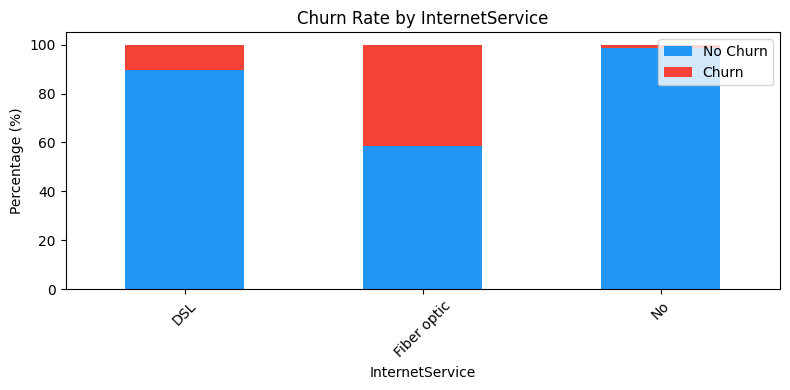

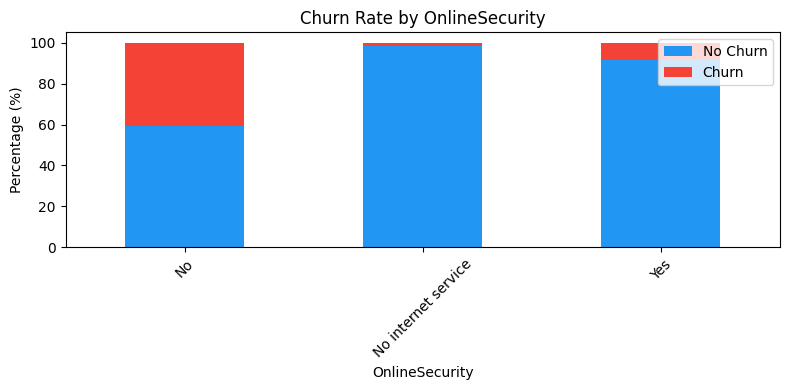

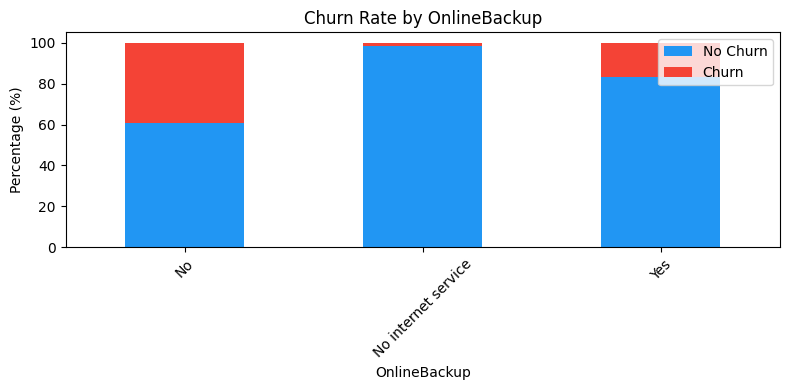

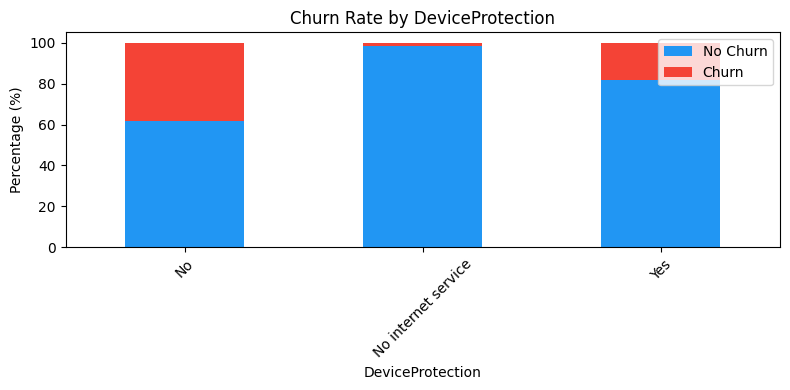

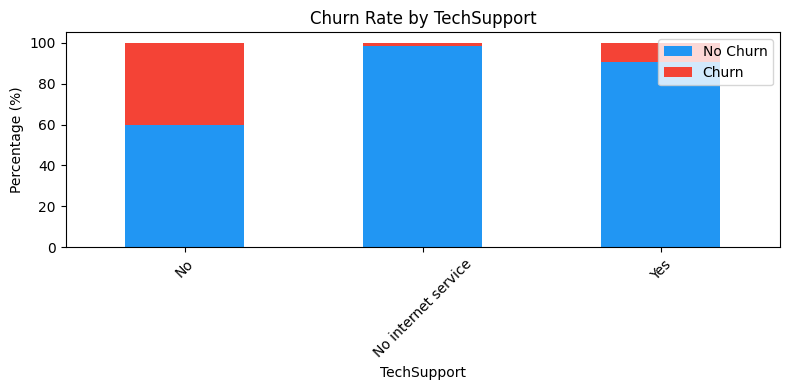

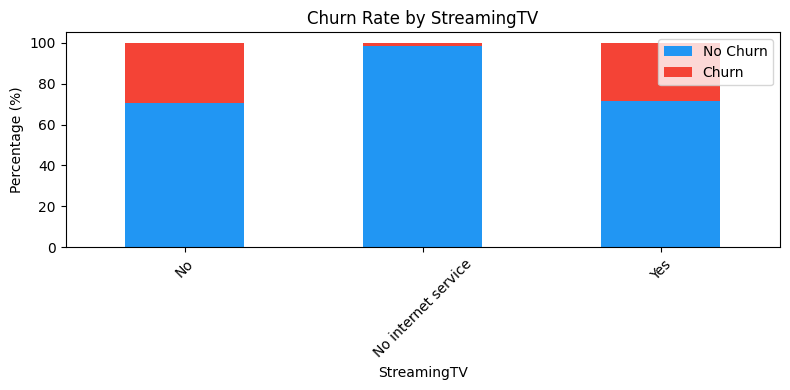

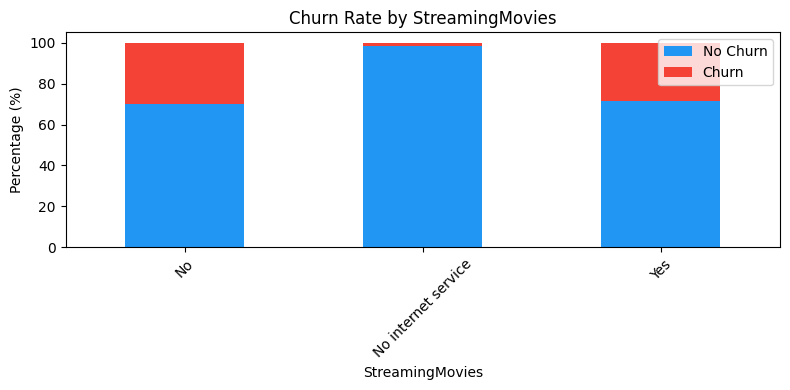

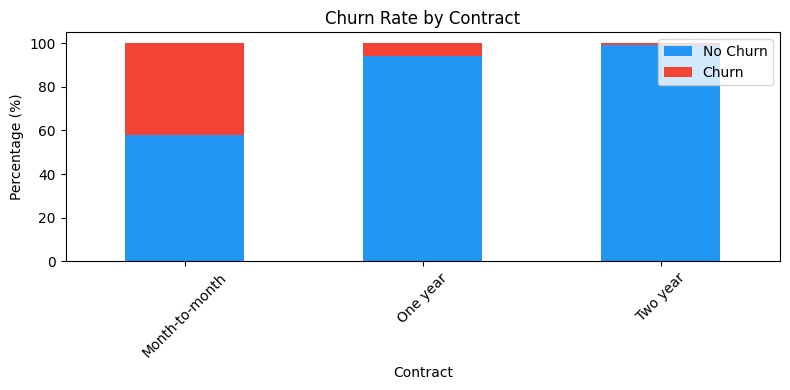

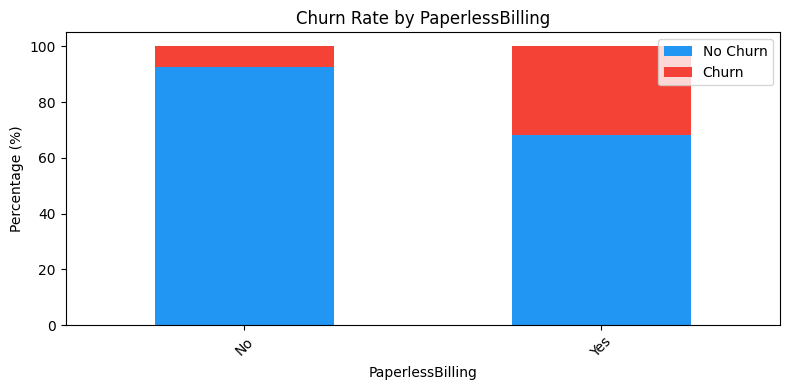

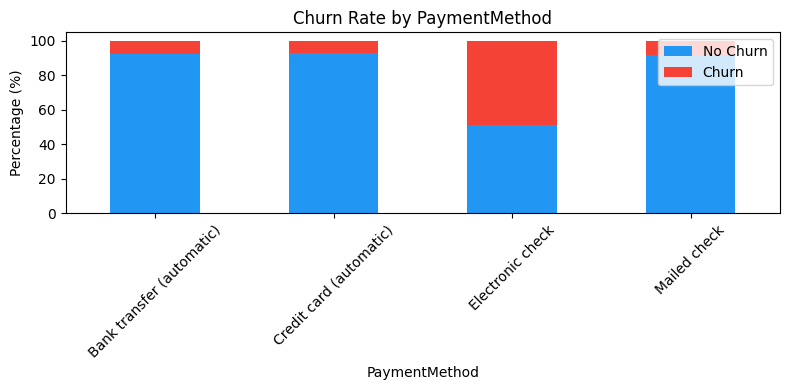

In [ ]:
cat_cols = train.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    ct = pd.crosstab(train[col], train['Churn'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, figsize=(8, 4),
            color=['#2196F3', '#F44336'])
    plt.title(f'Churn Rate by {col}')
    plt.ylabel('Percentage (%)')
    plt.xlabel(col)
    plt.legend(['No Churn', 'Churn'], loc='upper right')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

terdapat diagram mengenai faktor korelasi dengan churn dan non churn dimana seperti Churn Rate by Gender diagram menunjukkan bahwa Pelanggan Female dan Male memiliki pola churn yang hampir sama, dengan sekitar 77–78% pelanggan tetap bertahan dan sekitar 22–23% melakukan churn sehingga Perbedaan tingkat churn antara gender terlihat sangat kecil, sehingga fitur gender kemungkinan tidak memiliki pengaruh yang signifikan terhadap keputusan pelanggan untuk berhenti berlangganan. Hal ini berbeda dengan diagram Churn Rate by Partner bisa dilihat bahwa Proporsi Churn Lebih Tinggi pada Pengguna Tanpa Partner: Pelanggan yang tidak memiliki partner (No) memiliki tingkat churn yang jauh lebih tinggi (sekitar 33%) dibandingkan dengan pelanggan yang memiliki partne sedangkan Loyalitas Pengguna Berpartner: Pelanggan yang memiliki partner (Yes) cenderung lebih loyal, dengan tingkat retensi (No Churn) mencapai lebih dari 80% (sekitar 86%). Sehingga ada korelasi yaitu Terdapat indikasi bahwa dukungan atau keterikatan sosial (memiliki partner) berkontribusi positif terhadap retensi pelanggan dalam layanan ini. Begitu juga dengan diagram pada Churn Rate by Dependents memiliki korelasi bahwa Pelanggan dengan tanggungan cenderung memiliki pola penggunaan layanan yang lebih stabil dan tidak mudah berhenti berlangganan dibandingkan mereka yang tidak memiliki tanggungan. Pada diagram Churn Rate by PhoneService Pelanggan yang menggunakan layanan telepon (Yes) memiliki tingkat churn yang sedikit lebih tinggi (sekitar 25%) dibandingkan dengan pelanggan yang tidak menggunakan layanan telepon (No). Dari diagram tersebut bisa dilihat Risiko Tinggi pada Fiber Optic: Pelanggan dengan layanan Fiber optic memiliki tingkat churn yang paling ekstrem, mencapai lebih dari 40%. Ini menunjukkan adanya masalah pada kepuasan pelanggan atau harga di segmen ini dan Layanan DSL jauh lebih stabil dengan tingkat churn yang rendah (sekitar 10%) sedangkan Loyalitas Tanpa Internet: Pelanggan yang tidak menggunakan layanan internet (No) adalah kelompok yang paling loyal dengan tingkat churn mendekati 0%.


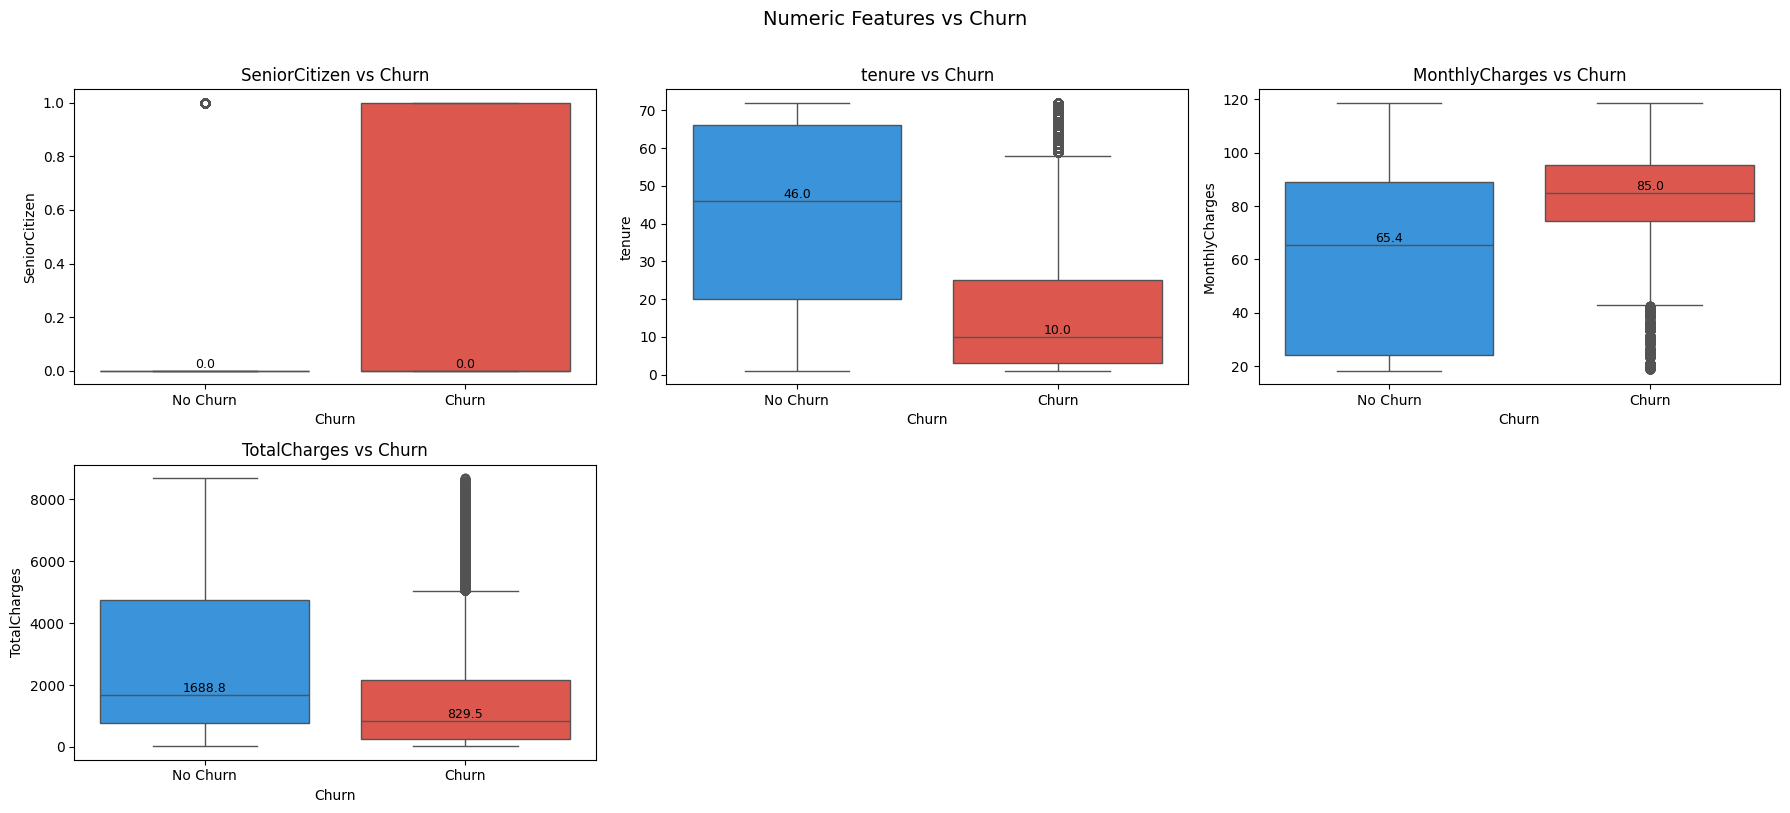

In [ ]:
numeric_features = [c for c in train.select_dtypes(include=np.number).columns
                    if c not in ['id', 'Churn']]
n = len(numeric_features)
cols = 3
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.boxplot(data=train, x='Churn', y=col, ax=axes[i],
                palette=['#2196F3', '#F44336'])  # ← pakai list, bukan dict
    axes[i].set_title(f'{col} vs Churn')
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['No Churn', 'Churn'])

    # Median annotation
    medians = train.groupby('Churn')[col].median()
    for j, median in enumerate(medians):
        axes[i].text(j, median, f'{median:.1f}', ha='center', va='bottom', fontsize=9)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numeric Features vs Churn', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

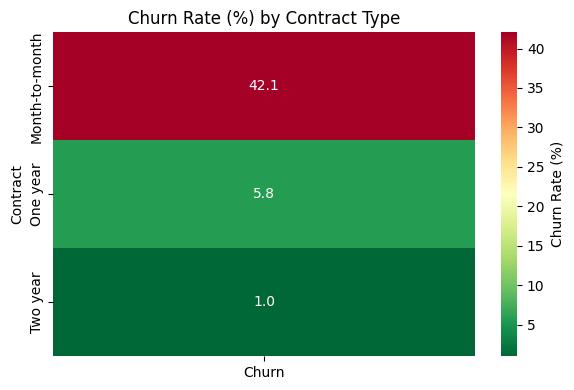

In [ ]:
pivot = train.pivot_table(
    values='Churn',
    index='Contract',
    aggfunc='mean'
) * 100

plt.figure(figsize=(6, 4))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
            cbar_kws={'label': 'Churn Rate (%)'})
plt.title('Churn Rate (%) by Contract Type')
plt.tight_layout()
plt.show()

Berdasarkan heatmap di atas, terlihat hubungan yang sangat kuat antara durasi kontrak dengan tingkat kehilangan pelanggan (churn):
*   Month-to-month (Kontrak Bulanan): Memiliki tingkat churn tertinggi yang sangat signifikan, yaitu 42.1%. Pelanggan dengan skema ini cenderung jauh lebih mudah berhenti berlangganan.
*   One year (Kontrak 1 Tahun): Tingkat churn menurun drastis menjadi 5.8%, menunjukkan bahwa komitmen satu tahun meningkatkan loyalitas pelanggan secara signifikan.
*   Two year (Kontrak 2 Tahun): Memiliki tingkat churn paling rendah, hanya sebesar 1.0%. Pelanggan dengan kontrak jangka panjang ini adalah kelompok yang paling stabil dan loyal.

Tipe kontrak merupakan variabel prediktor paling krusial. Strategi retensi harus difokuskan pada upaya mengonversi pelanggan month-to-month menjadi kontrak minimal satu tahun untuk menurunkan risiko churn secara efektif.





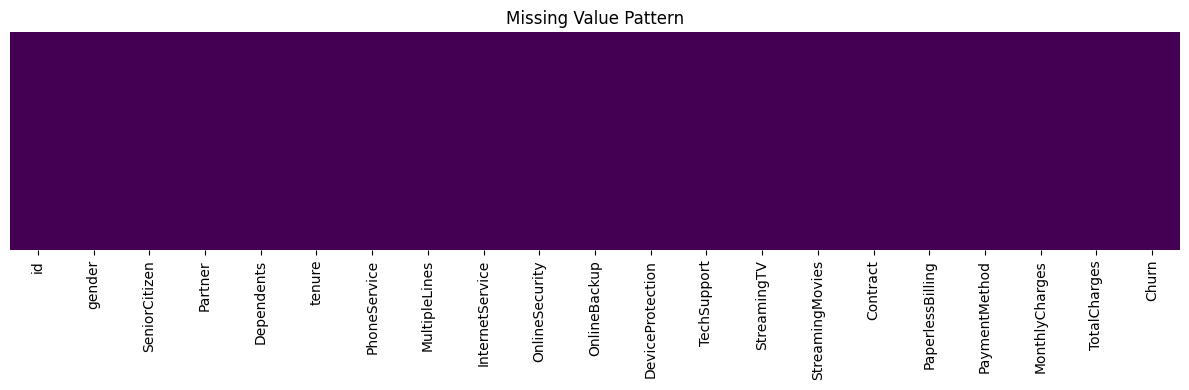

In [ ]:
plt.figure(figsize=(12, 4))
sns.heatmap(train.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Value Pattern')
plt.tight_layout()
plt.show()

In [ ]:
# Cell 5: Feature Engineering & Preprocessing
def preprocess(df, fit_encoders=True, encoders=None):
    df = df.copy()

    # Pisahkan ID
    ids = df['id'] if 'id' in df.columns else None

    # Drop kolom yang tidak relevan
    drop_cols = ['id']
    df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

    # Identifikasi kolom kategorik & numerik
    cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if 'Churn' in num_cols:
        num_cols.remove('Churn')

    # Fill missing values
    for col in num_cols:
        df[col] = df[col].fillna(df[col].median())
    for col in cat_cols:
        df[col] = df[col].fillna(df[col].mode()[0])

    # Label Encoding untuk kategorik
    if encoders is None:
        encoders = {}
    for col in cat_cols:
        if fit_encoders:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))
            encoders[col] = le
        else:
            le = encoders[col]
            df[col] = df[col].astype(str).map(
                lambda x: le.transform([x])[0] if x in le.classes_ else -1
            )

    return df, encoders, ids

# Fit pada train, transform test
train_proc, encoders, train_ids = preprocess(train, fit_encoders=True)
test_proc, _, test_ids         = preprocess(test, fit_encoders=False, encoders=encoders)

# Pisahkan features dan target
target_col = 'Churn'
X = train_proc.drop(columns=[target_col])
y = train_proc[target_col]
X_test = test_proc

print(f"X shape     : {X.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Target dist :\n{y.value_counts()}")

X shape     : (594194, 19)
X_test shape: (254655, 19)
Target dist :
Churn
0    460377
1    133817
Name: count, dtype: int64


In [ ]:
# Cell 6: Model Training dengan Cross-Validation (Out-Of-Fold)
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

# Inisialisasi array untuk OOF predictions & test predictions
oof_lgb  = np.zeros(len(X))
oof_xgb  = np.zeros(len(X))
oof_cat  = np.zeros(len(X))
pred_lgb = np.zeros(len(X_test))
pred_xgb = np.zeros(len(X_test))
pred_cat = np.zeros(len(X_test))

lgb_params = {
    'objective'      : 'binary',
    'metric'         : 'auc',
    'learning_rate'  : 0.05,
    'num_leaves'     : 63,
    'max_depth'      : -1,
    'n_estimators'   : 1000,
    'subsample'      : 0.8,
    'colsample_bytree': 0.8,
    'random_state'   : 42,
    'verbose'        : -1,
}

xgb_params = {
    'objective'       : 'binary:logistic',
    'eval_metric'     : 'auc',
    'learning_rate'   : 0.05,
    'max_depth'       : 6,
    'n_estimators'    : 1000,
    'subsample'       : 0.8,
    'colsample_bytree': 0.8,
    'random_state'    : 42,
    'verbosity'       : 0,
}

cat_params = {
    'iterations'   : 1000,
    'learning_rate': 0.05,
    'depth'        : 6,
    'random_seed'  : 42,
    'verbose'      : 0,
}

print("🚀 Starting Cross-Validation...\n")
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # --- LightGBM ---
    model_lgb = lgb.LGBMClassifier(**lgb_params)
    model_lgb.fit(X_tr, y_tr,
                  eval_set=[(X_val, y_val)],
                  callbacks=[lgb.early_stopping(50, verbose=False),
                              lgb.log_evaluation(period=-1)])
    oof_lgb[val_idx]  = model_lgb.predict_proba(X_val)[:, 1]
    pred_lgb          += model_lgb.predict_proba(X_test)[:, 1] / N_SPLITS

    # --- XGBoost ---
    model_xgb = xgb.XGBClassifier(**xgb_params, early_stopping_rounds=50)
    model_xgb.fit(X_tr, y_tr,
                  eval_set=[(X_val, y_val)],
                  verbose=False)
    oof_xgb[val_idx]  = model_xgb.predict_proba(X_val)[:, 1]
    pred_xgb          += model_xgb.predict_proba(X_test)[:, 1] / N_SPLITS

    # --- CatBoost ---
    model_cat = CatBoostClassifier(**cat_params)
    model_cat.fit(X_tr, y_tr,
                  eval_set=(X_val, y_val),
                  early_stopping_rounds=50)
    oof_cat[val_idx]  = model_cat.predict_proba(X_val)[:, 1]
    pred_cat          += model_cat.predict_proba(X_test)[:, 1] / N_SPLITS

    auc_lgb = roc_auc_score(y_val, oof_lgb[val_idx])
    auc_xgb = roc_auc_score(y_val, oof_xgb[val_idx])
    auc_cat = roc_auc_score(y_val, oof_cat[val_idx])
    print(f"Fold {fold+1} | LGB: {auc_lgb:.5f} | XGB: {auc_xgb:.5f} | CAT: {auc_cat:.5f}")

print(f"\n✅ OOF AUC — LGB: {roc_auc_score(y, oof_lgb):.5f} | XGB: {roc_auc_score(y, oof_xgb):.5f} | CAT: {roc_auc_score(y, oof_cat):.5f}")

🚀 Starting Cross-Validation...

Fold 1 | LGB: 0.91544 | XGB: 0.91603 | CAT: 0.91593
Fold 2 | LGB: 0.91677 | XGB: 0.91702 | CAT: 0.91705
Fold 3 | LGB: 0.91611 | XGB: 0.91651 | CAT: 0.91630
Fold 4 | LGB: 0.91714 | XGB: 0.91765 | CAT: 0.91739
Fold 5 | LGB: 0.91445 | XGB: 0.91488 | CAT: 0.91469

✅ OOF AUC — LGB: 0.91597 | XGB: 0.91641 | CAT: 0.91626


🏆 Ensemble OOF AUC: 0.91651


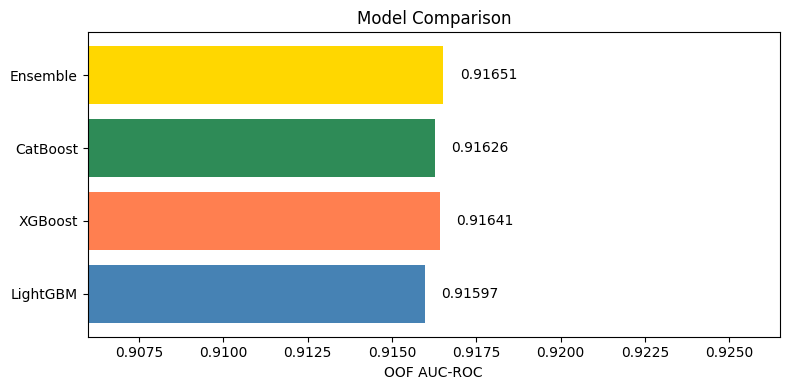

In [ ]:
# Cell 7: Ensemble Predictions
# Weighted average — bisa di-tune sesuai OOF AUC masing-masing model
w_lgb, w_xgb, w_cat = 0.4, 0.3, 0.3

oof_ensemble  = w_lgb * oof_lgb  + w_xgb * oof_xgb  + w_cat * oof_cat
pred_ensemble = w_lgb * pred_lgb + w_xgb * pred_xgb + w_cat * pred_cat

auc_ensemble = roc_auc_score(y, oof_ensemble)
print(f"🏆 Ensemble OOF AUC: {auc_ensemble:.5f}")

# Visualisasi perbandingan model
models = ['LightGBM', 'XGBoost', 'CatBoost', 'Ensemble']
aucs   = [roc_auc_score(y, oof_lgb),
          roc_auc_score(y, oof_xgb),
          roc_auc_score(y, oof_cat),
          auc_ensemble]

plt.figure(figsize=(8, 4))
bars = plt.barh(models, aucs, color=['steelblue','coral','seagreen','gold'])
plt.xlim(min(aucs) - 0.01, max(aucs) + 0.01)
plt.xlabel('OOF AUC-ROC')
plt.title('Model Comparison')
for bar, auc in zip(bars, aucs):
    plt.text(auc + 0.0005, bar.get_y() + bar.get_height()/2,
             f'{auc:.5f}', va='center')
plt.tight_layout()
plt.show()

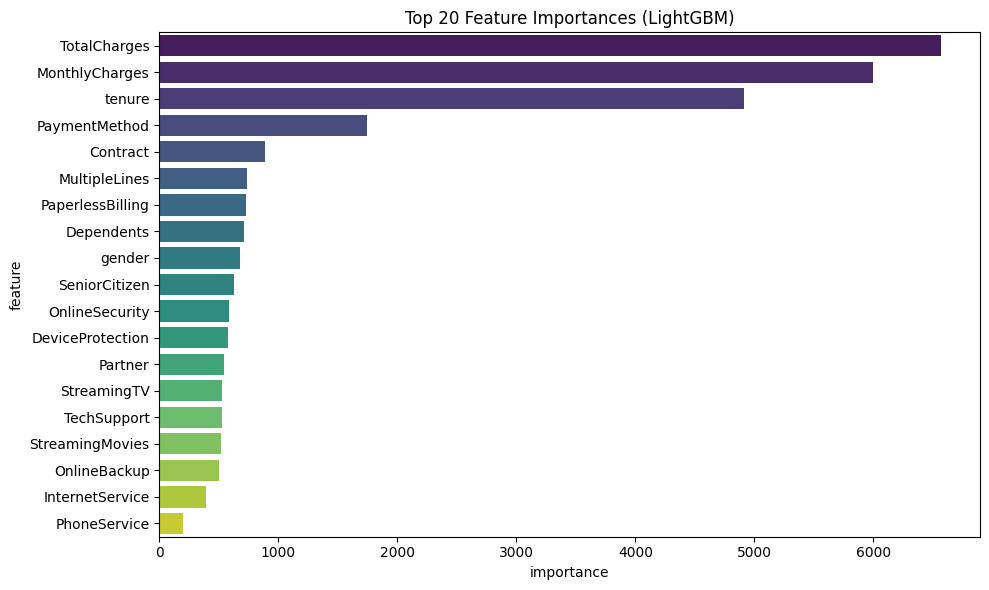

In [ ]:
# Cell 8: Feature Importance (LightGBM)
feat_imp = pd.DataFrame({
    'feature'   : X.columns,
    'importance': model_lgb.feature_importances_
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp, x='importance', y='feature', palette='viridis')
plt.title('Top 20 Feature Importances (LightGBM)')
plt.tight_layout()
plt.show()

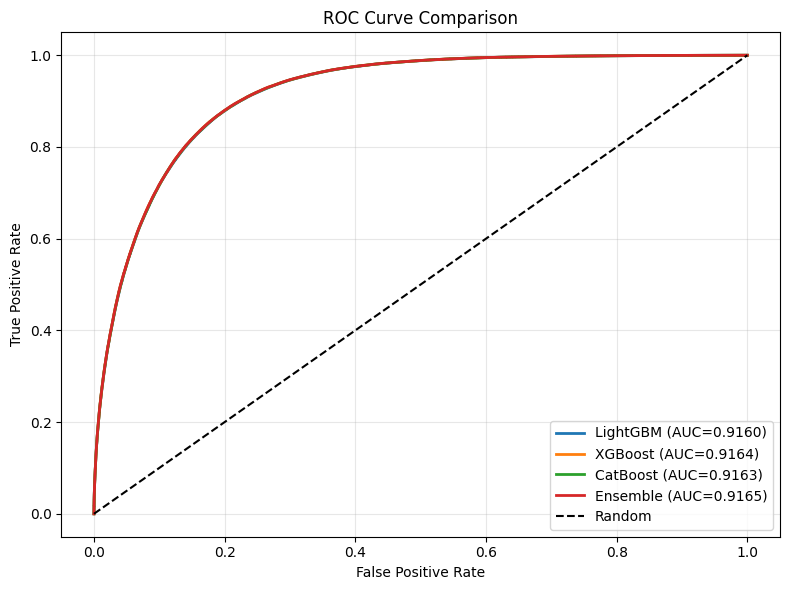

In [ ]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(8, 6))

for name, oof in [('LightGBM', oof_lgb), ('XGBoost', oof_xgb),
                   ('CatBoost', oof_cat), ('Ensemble', oof_ensemble)]:
    fpr, tpr, _ = roc_curve(y, oof)
    auc = roc_auc_score(y, oof)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})', linewidth=2)

ax.plot([0,1],[0,1], 'k--', label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

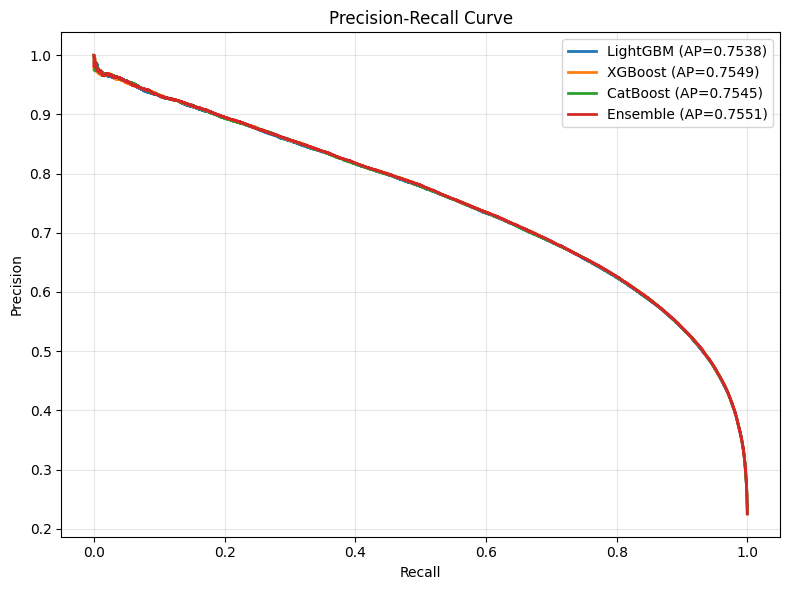

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(figsize=(8, 6))

for name, oof in [('LightGBM', oof_lgb), ('XGBoost', oof_xgb),
                   ('CatBoost', oof_cat), ('Ensemble', oof_ensemble)]:
    prec, rec, _ = precision_recall_curve(y, oof)
    ap = average_precision_score(y, oof)
    ax.plot(rec, prec, label=f'{name} (AP={ap:.4f})', linewidth=2)

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Threshold Optimal: 0.35


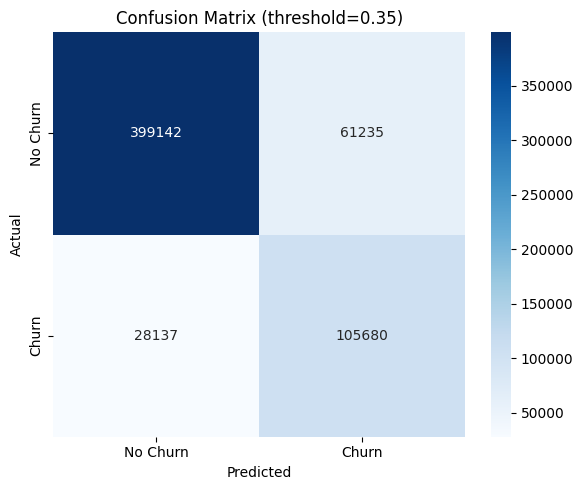

              precision    recall  f1-score   support

    No Churn       0.93      0.87      0.90    460377
       Churn       0.63      0.79      0.70    133817

    accuracy                           0.85    594194
   macro avg       0.78      0.83      0.80    594194
weighted avg       0.87      0.85      0.86    594194



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Cari threshold optimal berdasarkan F1
from sklearn.metrics import f1_score
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = [f1_score(y, (oof_ensemble >= t).astype(int)) for t in thresholds]
best_thresh = thresholds[np.argmax(f1_scores)]
print(f"Threshold Optimal: {best_thresh:.2f}")

y_pred = (oof_ensemble >= best_thresh).astype(int)
cm = confusion_matrix(y, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
ax.set_title(f'Confusion Matrix (threshold={best_thresh:.2f})')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

print(classification_report(y, y_pred, target_names=['No Churn', 'Churn']))

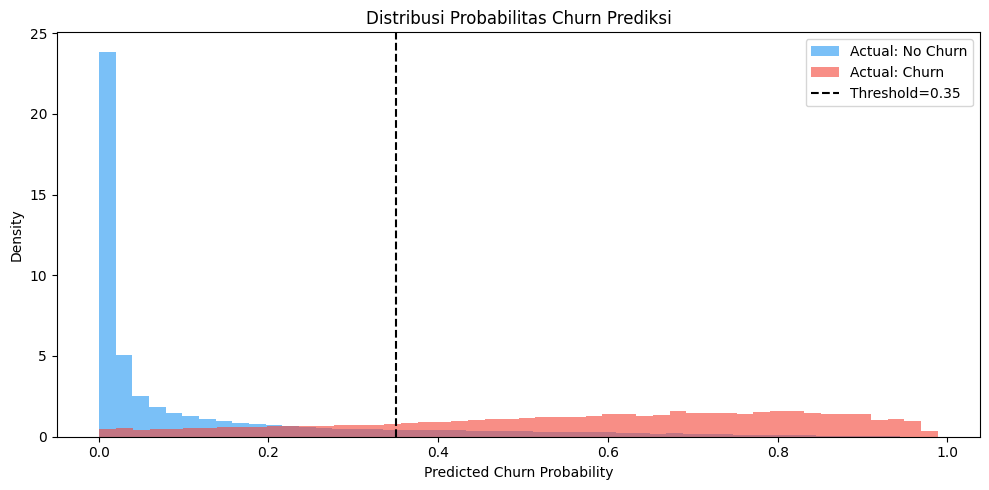

risk_segment
🟢 Low Risk       178584
🟡 Medium Risk     39566
🔴 High Risk       36505
Name: count, dtype: int64


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

# Pisahkan berdasarkan actual label
ax.hist(oof_ensemble[y==0], bins=50, alpha=0.6, color='#2196F3',
        label='Actual: No Churn', density=True)
ax.hist(oof_ensemble[y==1], bins=50, alpha=0.6, color='#F44336',
        label='Actual: Churn', density=True)
ax.axvline(best_thresh, color='black', linestyle='--', label=f'Threshold={best_thresh:.2f}')

ax.set_xlabel('Predicted Churn Probability')
ax.set_ylabel('Density')
ax.set_title('Distribusi Probabilitas Churn Prediksi')
ax.legend()
plt.tight_layout()
plt.show()

# Segmentasi risiko pada test set
risk_df = pd.DataFrame({
    'id': test_ids,
    'churn_prob': pred_ensemble
})
risk_df['risk_segment'] = pd.cut(risk_df['churn_prob'],
                                  bins=[0, 0.3, 0.6, 1.0],
                                  labels=['🟢 Low Risk', '🟡 Medium Risk', '🔴 High Risk'])
print(risk_df['risk_segment'].value_counts())